<a href="https://colab.research.google.com/github/kamilrewera-analyst/global_sales_data_analysis_python/blob/main/Global_E_Commerce_Sales_%26_Supply_Chain_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Wstepne zapoznanie się z danymi i ich zawartością.

In [ ]:
import calendar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/COLAB/FILES/MT

events_data = pd.read_csv('events.csv')
products_data = pd.read_csv('products.csv')
countries_data = pd.read_csv('countries.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/COLAB/FILES/MT


#2. Czyszczenie danych

##Events data

In [ ]:
events_data.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
events_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
print(f"Missing values per column:\n{events_data.isna().sum()}")
print(10 *'-')
print(f"Duplicated values: {events_data.duplicated().sum()}")

Missing values per column:
Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64
----------
Duplicated values: 0


In [ ]:
print(events_data.isna().sum() / events_data.shape[0] * 100)

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [ ]:
clean_events_data = events_data.dropna(subset=['Units Sold'])

clean_events_data.loc[:,'Country Code'] = clean_events_data['Country Code'].fillna('unknown')

In [ ]:
clean_events_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1328 non-null   int64  
 1   Order Date      1328 non-null   object 
 2   Ship Date       1328 non-null   object 
 3   Order Priority  1328 non-null   object 
 4   Country Code    1328 non-null   object 
 5   Product ID      1328 non-null   int64  
 6   Sales Channel   1328 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1328 non-null   float64
 9   Unit Cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 114.1+ KB


##Products data

In [ ]:
products_data.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
products_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
print(f"Null value summary:\n{products_data.isna().sum()}")
print(10 *'-')
print(f"Duplicated value summary:{products_data.duplicated().sum()}")

clean_products_data = products_data

Null value summary:
id           0
item_type    0
dtype: int64
----------
Duplicated value summary:0


##Countries data

In [ ]:
countries_data.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
countries_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
print(f"Null value summary:\n{countries_data.isna().sum()}")
print(10 *'-')
print(f"Duplicated value summary:{countries_data.duplicated().sum()}")

Null value summary:
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64
----------
Duplicated value summary:0


In [ ]:
#Identify rows with missing region and sub-region values
countries_no_region = countries_data[countries_data['region'].isna()]
countries_no_sub_region = countries_data[countries_data['sub-region'].isna()]

#Verifying relationships between missing values and country codes in events_data.
antarctica_sale = events_data[events_data['Country Code'] == 'ATA']
nambia_sale = events_data[events_data['Country Code'] == 'NAM']

clean_countries_data = countries_data.dropna()

#3. Analiza i wizualizacja danych

##Łączenie danych

In [ ]:
mege_1 = clean_events_data.merge(
    clean_products_data,
    left_on = 'Product ID',
    right_on = 'id',
    how = 'inner'
    )

clean_sales_data = mege_1.merge(
    clean_countries_data,
    left_on = 'Country Code',
    right_on = 'alpha-3',
    how = 'left'
    )

clean_sales_data = clean_sales_data.drop(
    columns=['alpha-2',
             'alpha-3',
             'id'])

In [ ]:
clean_sales_data['Order Date'] = pd.to_datetime(clean_sales_data['Order Date'])
clean_sales_data['Ship Date'] = pd.to_datetime(clean_sales_data['Ship Date'])

clean_sales_data = clean_sales_data.rename(columns={'name': 'country'})
clean_sales_data = clean_sales_data.rename(columns={'sub-region': 'sub_region'})
clean_sales_data = clean_sales_data.rename(columns={'item_type': 'product_category'})

clean_sales_data.rename(columns=str.lower, inplace=True)
clean_sales_data.columns = clean_sales_data.columns.str.replace(' ', '_')

#Filling missing values
clean_sales_data[['country', 'region', 'sub_region']] = clean_sales_data[['country', 'region', 'sub_region']].fillna('Unknown')

#Adding columns for key sales metrics
clean_sales_data['order_revenue'] = clean_sales_data['units_sold'] * clean_sales_data['unit_price']
clean_sales_data['order_cost'] = clean_sales_data['units_sold'] * clean_sales_data['unit_cost']
clean_sales_data['order_profit'] = clean_sales_data['order_revenue'] - clean_sales_data['order_cost']

##Kluczowe wskaźniki firmy

###Główne wskaźniki statystyczne

In [ ]:
print(f"Total Revenue: {clean_sales_data['order_revenue'].sum()}")
print(f"Total Cost: {round(clean_sales_data['order_cost'].sum(), 2)}")
print(f"Total Profit: {clean_sales_data['order_profit'].sum()}")
print(f"\nAverage Revenue: {round(clean_sales_data['order_revenue'].mean(), 2)}")
print(f"Average Profit: {round(clean_sales_data['order_profit'].mean(), 2)}")

print(f"\nTotal Orders: {clean_sales_data['order_id'].count()}")
print(f"Total Units Sold: {int(clean_sales_data['units_sold'].sum())}")
print(f"Total Number of Product Categories: {clean_sales_data['product_category'].nunique()}")
print(f"Total Number of Countries: {clean_sales_data['country'].nunique()-1}")

Total Revenue: 1702129408.21
Total Cost: 1200694949.21
Total Profit: 501434459.0

Average Revenue: 1281723.95
Average Profit: 377586.19

Total Orders: 1328
Total Units Sold: 6576524
Total Number of Product Categories: 12
Total Number of Countries: 45


###Analiza sprzedaży wg.kategorii produktów

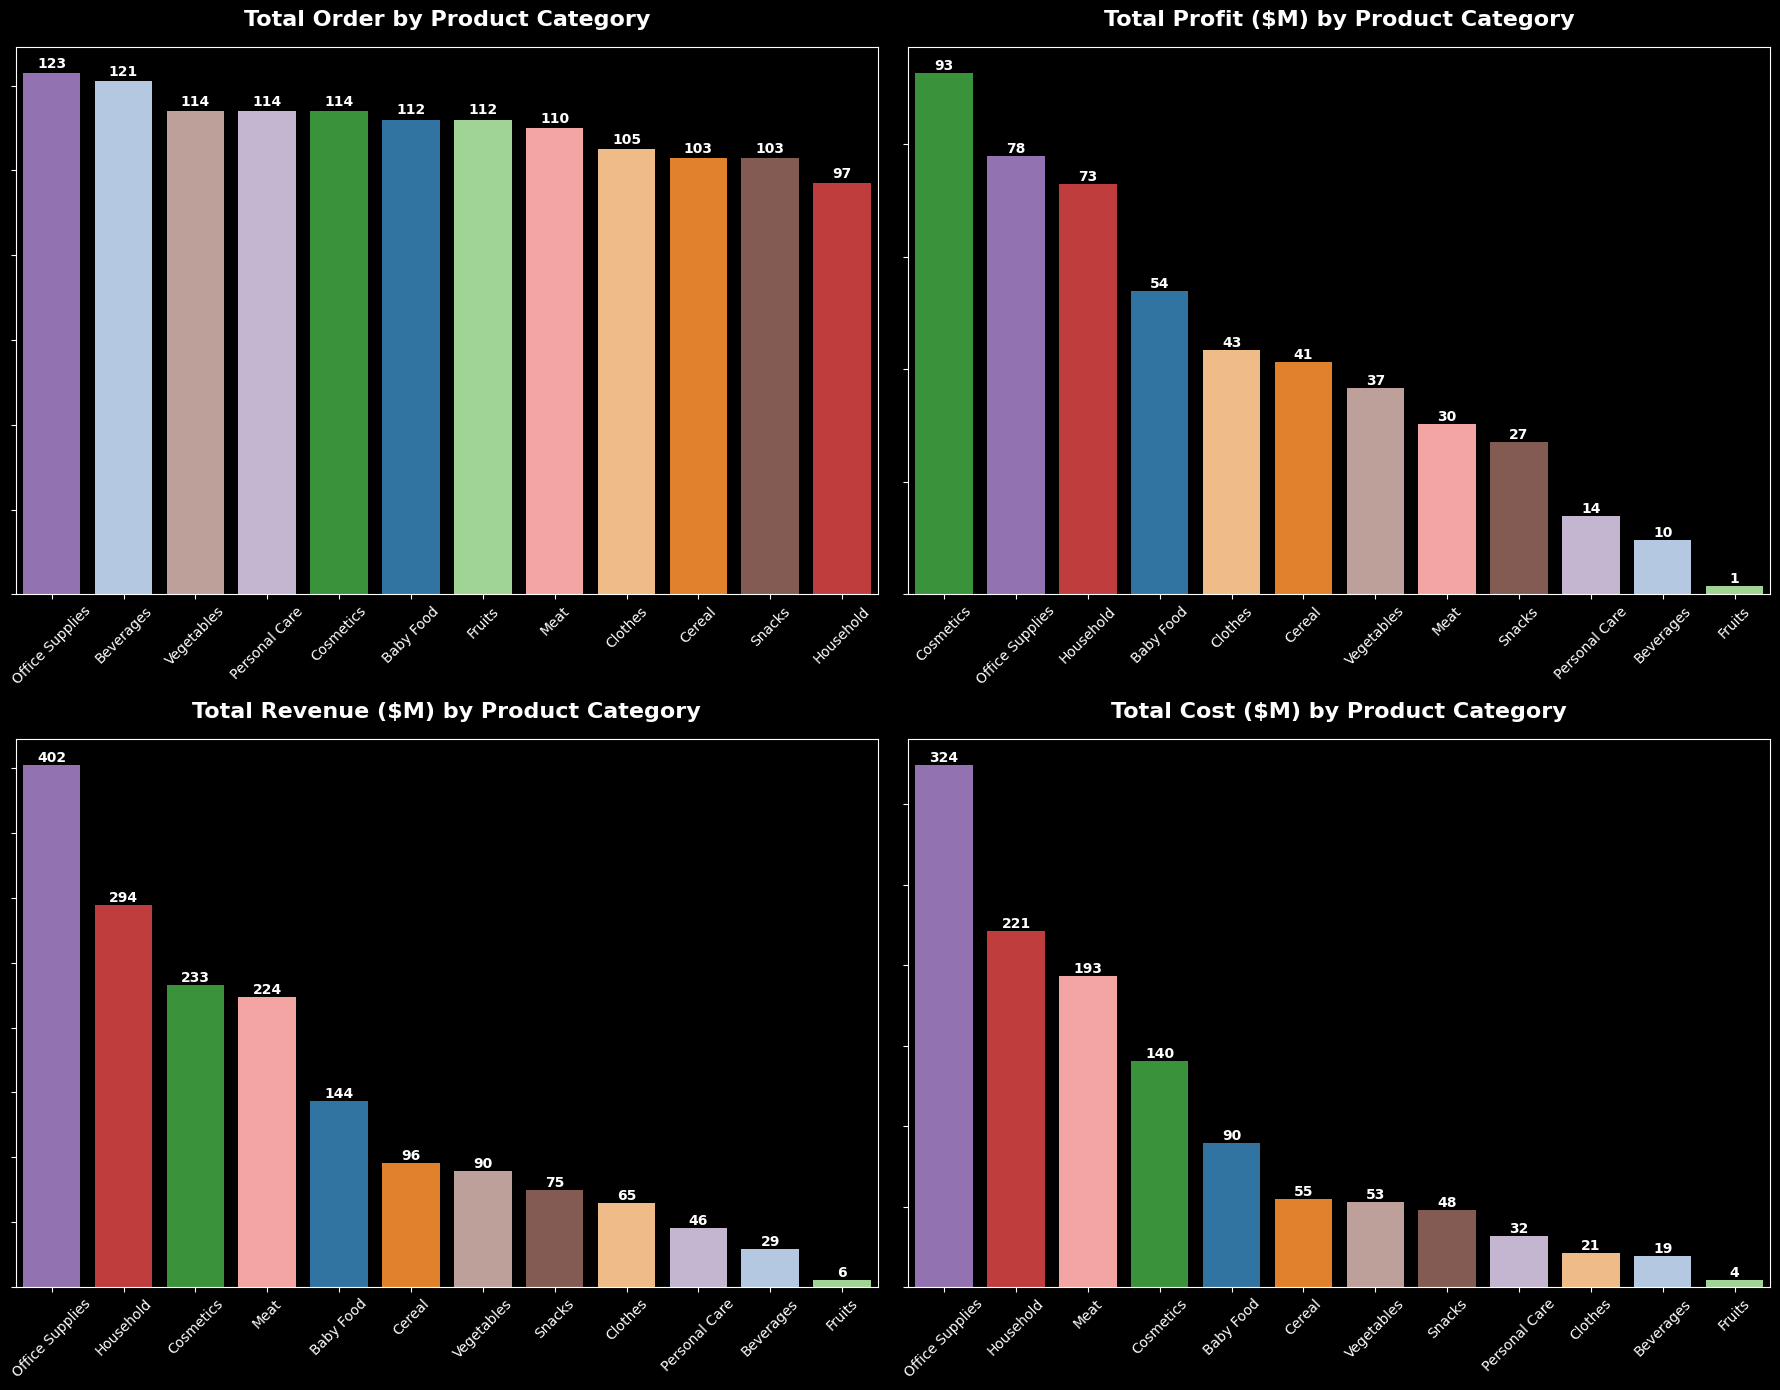

In [ ]:
plt.style.use('dark_background')

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

#Creating palette
category_list = sorted(clean_sales_data['product_category'].unique())
palette = sns.color_palette("tab20", n_colors=len(category_list))
category_colors = dict(zip(category_list, palette))

#1. Total Orders by category
order_list = clean_sales_data['product_category'].value_counts().index

sns.countplot(
    data = clean_sales_data,
    x = 'product_category',
    hue = 'product_category',
    palette = category_colors,
    order = order_list,
    ax = axes[0, 0],
    legend = False
    )

axes[0, 0].set_title(
    "Total Order by Product Category",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[0, 0].set_ylabel("")
axes[0, 0].set_xlabel("")
axes[0, 0].set_yticklabels([])
axes[0, 0].tick_params(axis='x', rotation=45)

for bar in axes[0, 0].patches:
    height = bar.get_height()
    if height > 0:
        axes[0, 0].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{int(height)}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#2. Total Profit by category
profit_order = clean_sales_data.groupby('product_category')['order_profit'].sum().sort_values(ascending=False).index

sns.barplot(
    data = clean_sales_data,
    x = 'product_category',
    y = 'order_profit',
    hue = 'product_category',
    palette = category_colors,
    estimator = 'sum',
    errorbar = None,
    order = profit_order,
    ax = axes[0, 1],
    legend = False
    )

axes[0, 1].set_title(
    "Total Profit ($M) by Product Category",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")
axes[0, 1].set_yticklabels([])
axes[0, 1].tick_params(axis='x', rotation=45)

for bar in axes[0, 1].patches:
    height = bar.get_height()
    if height > 0:
        axes[0, 1].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#3. Total Revenue by category
revenue_order = clean_sales_data.groupby('product_category')['order_revenue'].sum().sort_values(ascending=False).index

sns.barplot(
    data = clean_sales_data,
    x = 'product_category',
    y = 'order_revenue',
    hue = 'product_category',
    palette = category_colors,
    estimator = 'sum',
    errorbar = None,
    order = revenue_order,
    ax = axes[1, 0],
    legend = False
    )

axes[1, 0].set_title(
    "Total Revenue ($M) by Product Category",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[1, 0].set_ylabel("")
axes[1, 0].set_xlabel("")
axes[1, 0].set_yticklabels([])
axes[1, 0].tick_params(axis='x', rotation=45)

for bar in axes[1, 0].patches:
    height = bar.get_height()
    if height > 0:
        axes[1, 0].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#4. Total Cost by category
cost_order = clean_sales_data.groupby('product_category')['order_cost'].sum().sort_values(ascending=False).index

sns.barplot(
    data = clean_sales_data,
    x = 'product_category',
    y = 'order_cost',
    hue = 'product_category',
    palette = category_colors,
    estimator = 'sum',
    errorbar = None,
    order = cost_order,
    ax = axes[1, 1],
    legend = False
    )

axes[1, 1].set_title(
    "Total Cost ($M) by Product Category",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")
axes[1, 1].set_yticklabels([])
axes[1, 1].tick_params(axis='x', rotation=45)

for bar in axes[1, 1].patches:
    height = bar.get_height()
    if height > 0:
        axes[1, 1].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

plt.tight_layout()
plt.show()


Kategoria Office Supplies dominuje pod względem skali operacji, generując najwyższy przychód (402 mln USD) oraz największą liczbę zamówień. Mimo to najbardziej rentownym segmentem okazują się Cosmetics, które przy znacznie niższych kosztach dostarczają rekordowy zysk na poziomie 93 mln USD.

###Analiza sprzedaży wg. regionów

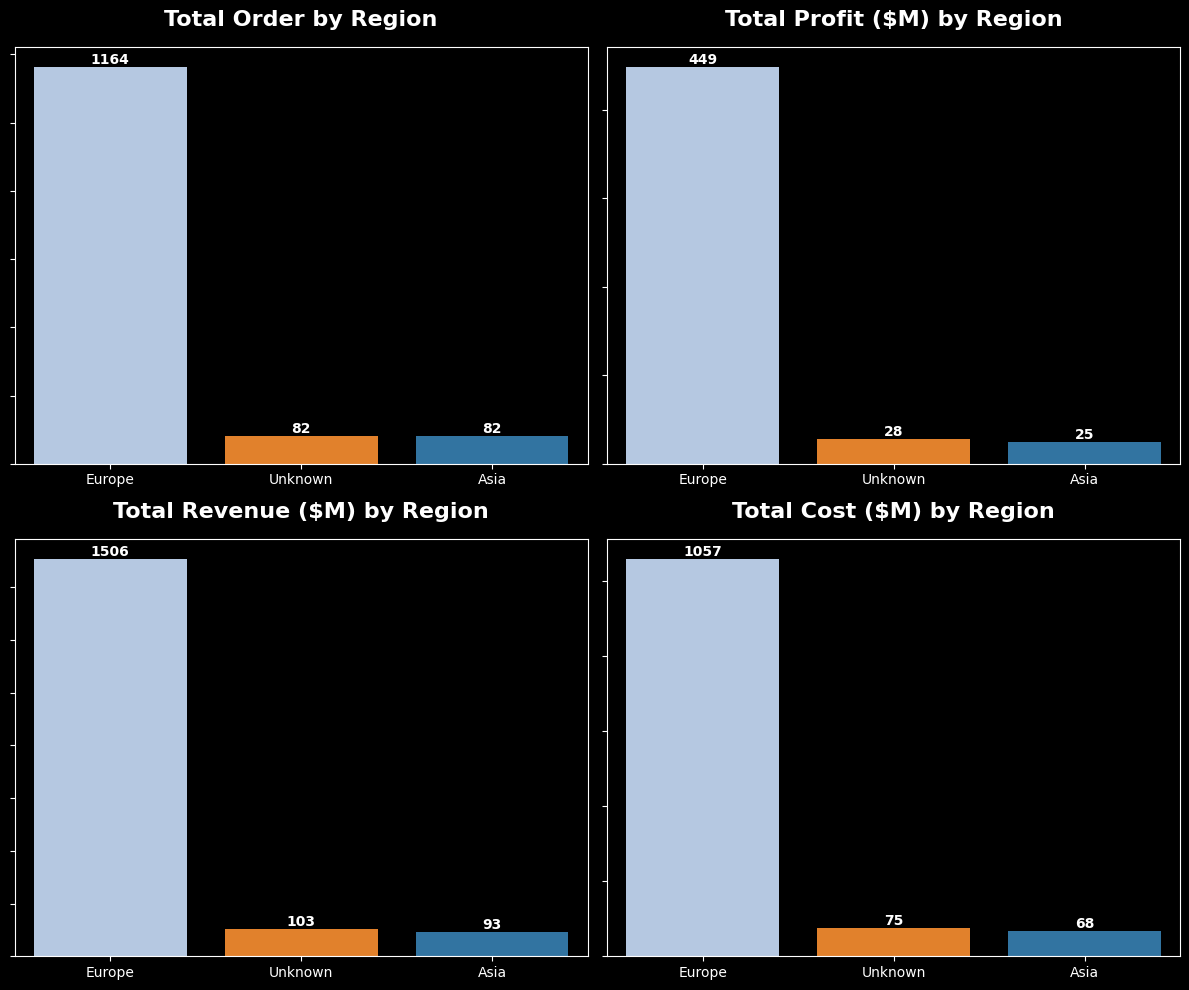

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Creating palette
region_list = sorted(clean_sales_data['region'].unique())
palette = sns.color_palette("tab20", n_colors=len(region_list))
region_colors = dict(zip(region_list, palette))

#1. Total Orders by region
order_list = clean_sales_data['region'].value_counts().index

sns.countplot(
    data = clean_sales_data,
    x = 'region',
    hue = 'region',
    palette = region_colors,
    order = order_list,
    ax = axes[0, 0],
    legend = False
    )

axes[0, 0].set_title(
    "Total Order by Region",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[0, 0].set_ylabel("")
axes[0, 0].set_xlabel("")
axes[0, 0].set_yticklabels([])

for bar in axes[0, 0].patches:
    height = bar.get_height()
    if height > 0:
        axes[0, 0].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{int(height)}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#2. Total Profit by region
profit_order = clean_sales_data.groupby('region')['order_profit'].sum().sort_values(ascending=False).index

sns.barplot(
    data = clean_sales_data,
    x = 'region',
    y = 'order_profit',
    hue = 'region',
    palette = region_colors,
    estimator = 'sum',
    errorbar = None,
    order = profit_order,
    ax = axes[0, 1],
    legend = False
    )

axes[0, 1].set_title(
    "Total Profit ($M) by Region",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")
axes[0, 1].set_yticklabels([])

for bar in axes[0, 1].patches:
    height = bar.get_height()
    if height > 0:
        axes[0, 1].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#3. Total Revenue by region
revenue_order = clean_sales_data.groupby('region')['order_revenue'].sum().sort_values(ascending=False).index

sns.barplot(
    data = clean_sales_data,
    x = 'region',
    y = 'order_revenue',
    hue = 'region',
    palette = region_colors,
    estimator = 'sum',
    errorbar = None,
    order = revenue_order,
    ax = axes[1, 0],
    legend = False
    )

axes[1, 0].set_title(
    "Total Revenue ($M) by Region",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[1, 0].set_ylabel("")
axes[1, 0].set_xlabel("")
axes[1, 0].set_yticklabels([])

for bar in axes[1, 0].patches:
    height = bar.get_height()
    if height > 0:
        axes[1, 0].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#4. Total Cost by region
cost_order = clean_sales_data.groupby('region')['order_cost'].sum().sort_values(ascending=False).index

sns.barplot(
    data = clean_sales_data,
    x = 'region',
    y = 'order_cost',
    hue = 'region',
    palette = region_colors,
    estimator = 'sum',
    errorbar = None,
    order = cost_order,
    ax = axes[1, 1],
    legend = False
    )

axes[1, 1].set_title(
    "Total Cost ($M) by Region",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")
axes[1, 1].set_yticklabels([])

for bar in axes[1, 1].patches:
    height = bar.get_height()
    if height > 0:
        axes[1, 1].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

plt.tight_layout()
plt.show()

**Europa** dominuje w każdym aspekcie działalności, generując **1 506 mln USD przychodu** i aż **449 mln USD zysku**, co stanowi miażdżącą większość wyników firmy. Pozostałe regiony mają marginalne znaczenie.

###Analiza sprzedaży wg. krajów

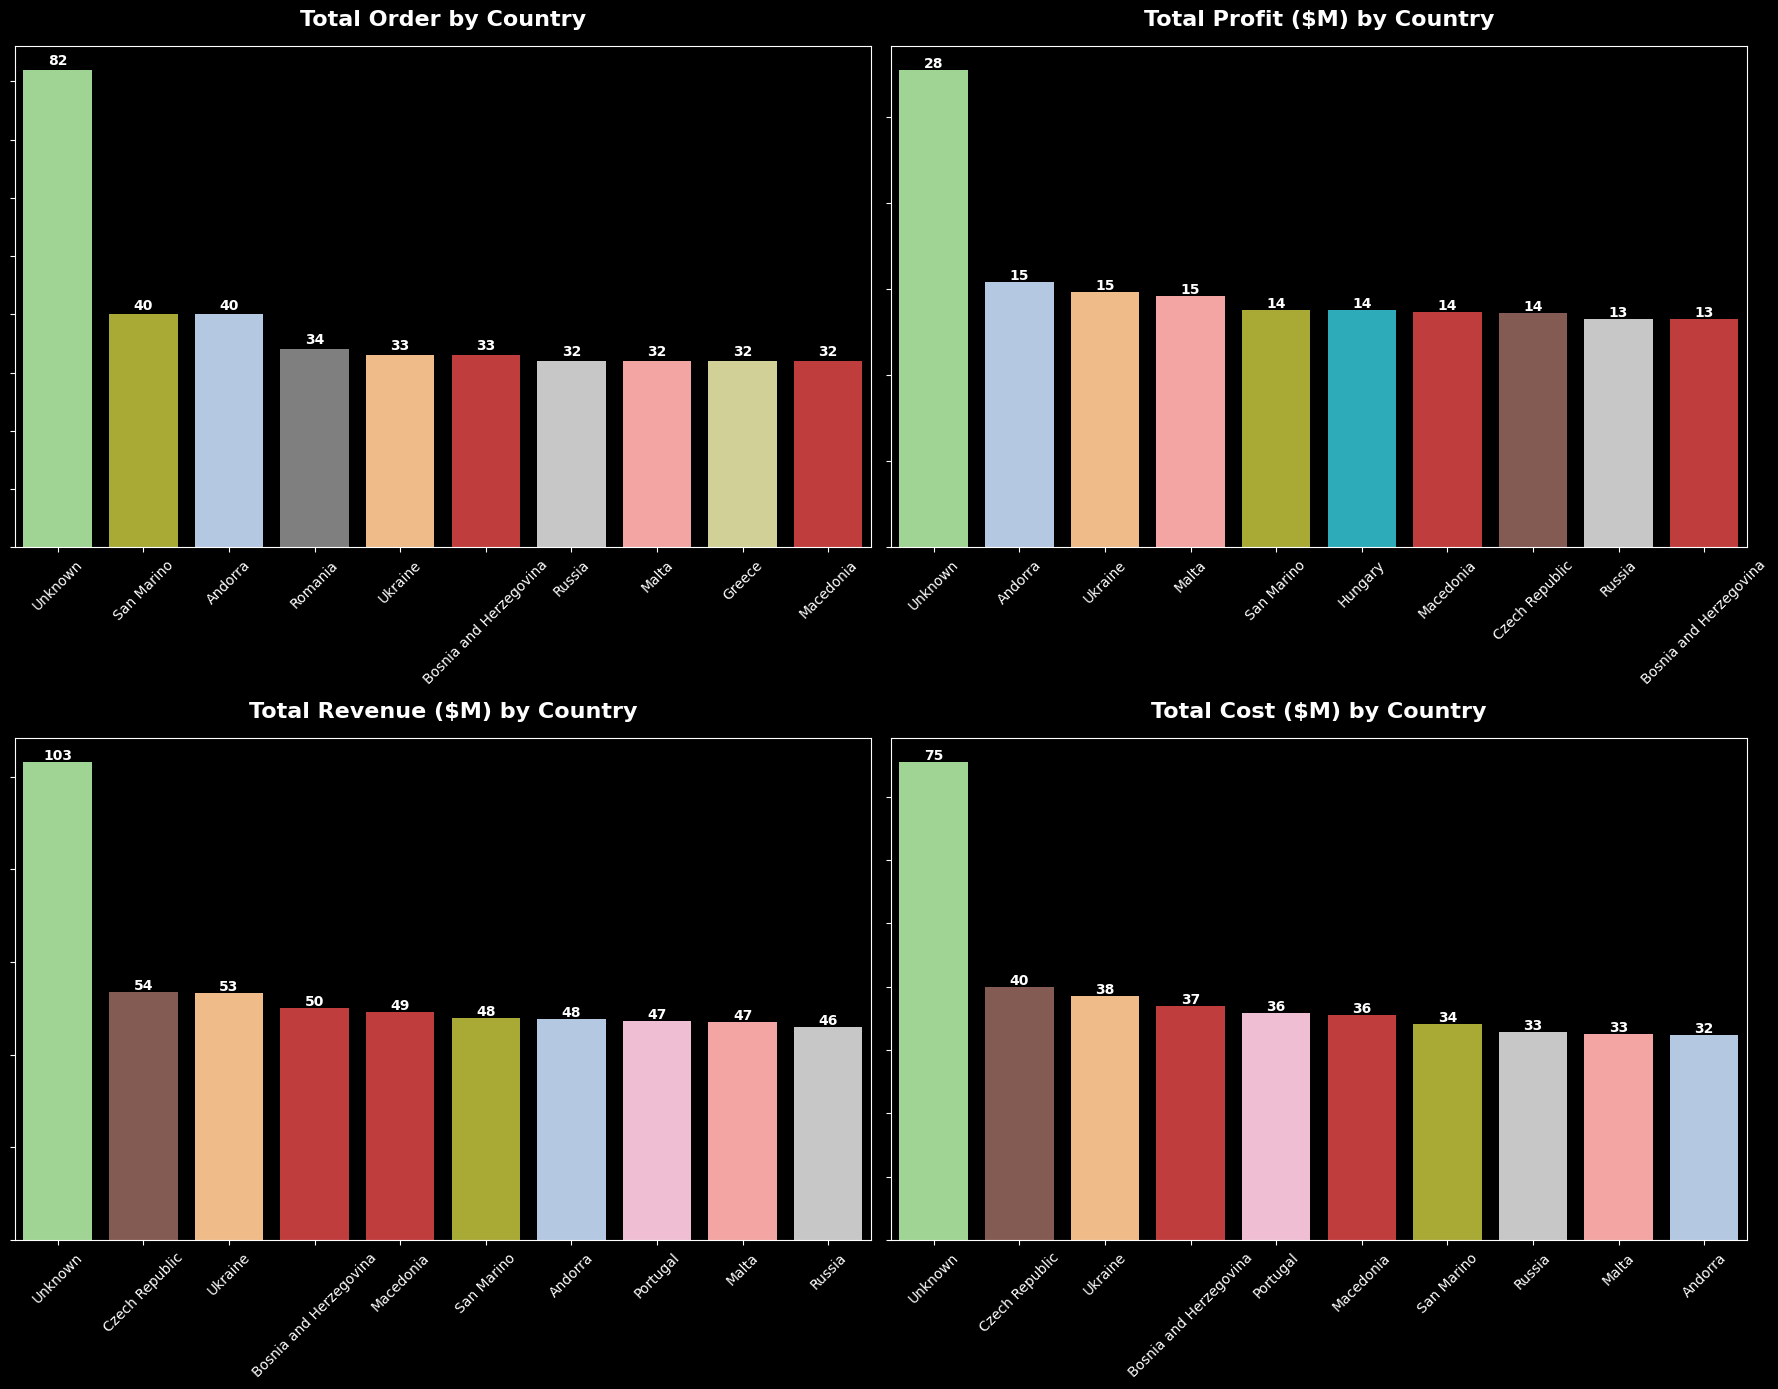

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

#Creating palette
country_list = sorted(clean_sales_data['country'].unique())
palette = sns.color_palette("tab20", n_colors=len(country_list))
country_colors = dict(zip(country_list, palette))

#1. Total Orders by country
order_list = clean_sales_data['country'].value_counts().head(10).index

sns.countplot(
    data = clean_sales_data,
    x = 'country',
    hue = 'country',
    palette = country_colors,
    order = order_list,
    ax = axes[0, 0],
    legend = False
    )

axes[0, 0].set_title(
    "Total Order by Country",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[0, 0].set_ylabel("")
axes[0, 0].set_xlabel("")
axes[0, 0].set_yticklabels([])
axes[0, 0].tick_params(axis='x', rotation=45)

for bar in axes[0, 0].patches:
    height = bar.get_height()
    if height > 0:
        axes[0, 0].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{int(height)}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#2. Total Profit by country
profit_order = clean_sales_data.groupby('country')['order_profit'].sum().sort_values(ascending=False).head(10).index

sns.barplot(
    data = clean_sales_data,
    x = 'country',
    y = 'order_profit',
    hue = 'country',
    palette = country_colors,
    estimator = 'sum',
    errorbar = None,
    order = profit_order,
    ax = axes[0, 1],
    legend = False
    )

axes[0, 1].set_title(
    "Total Profit ($M) by Country",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")
axes[0, 1].set_yticklabels([])
axes[0, 1].tick_params(axis='x', rotation=45)

for bar in axes[0, 1].patches:
    height = bar.get_height()
    if height > 0:
        axes[0, 1].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#3. Total Revenue by country
revenue_order = clean_sales_data.groupby('country')['order_revenue'].sum().sort_values(ascending=False).head(10).index

sns.barplot(
    data = clean_sales_data,
    x = 'country',
    y = 'order_revenue',
    hue = 'country',
    palette = country_colors,
    estimator = 'sum',
    errorbar = None,
    order = revenue_order,
    ax = axes[1, 0],
    legend = False
    )

axes[1, 0].set_title(
    "Total Revenue ($M) by Country",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[1, 0].set_ylabel("")
axes[1, 0].set_xlabel("")
axes[1, 0].set_yticklabels([])
axes[1, 0].tick_params(axis='x', rotation=45)

for bar in axes[1, 0].patches:
    height = bar.get_height()
    if height > 0:
        axes[1, 0].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#4. Total Cost by country
cost_order = clean_sales_data.groupby('country')['order_cost'].sum().sort_values(ascending=False).head(10).index

sns.barplot(
    data = clean_sales_data,
    x = 'country',
    y = 'order_cost',
    hue = 'country',
    palette = country_colors,
    estimator = 'sum',
    errorbar = None,
    order = cost_order,
    ax = axes[1, 1],
    legend = False
    )

axes[1, 1].set_title(
    "Total Cost ($M) by Country",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")
axes[1, 1].set_yticklabels([])
axes[1, 1].tick_params(axis='x', rotation=45)

for bar in axes[1, 1].patches:
    height = bar.get_height()
    if height > 0:
        axes[1, 1].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

plt.tight_layout()
plt.show()

Wizualizacja wskazuje na kluczową rolę kategorii **Unknown**, która przoduje we wszystkich metrykach, generując **103 mln USD przychodu** i **28 mln USD zysku**. Wśród zidentyfikowanych rynków największą skalę operacji wykazują **Czechy** i **Ukraina**, natomiast pod względem rentowności na pierwszy plan wysuwają się **Andora**, **Ukraina** oraz **Malta**, osiągając najwyższy **zysk** jednostkowy **na poziomie 15 mln USD**.

###Analiza sprzedaży wg. kanału sprzedaży

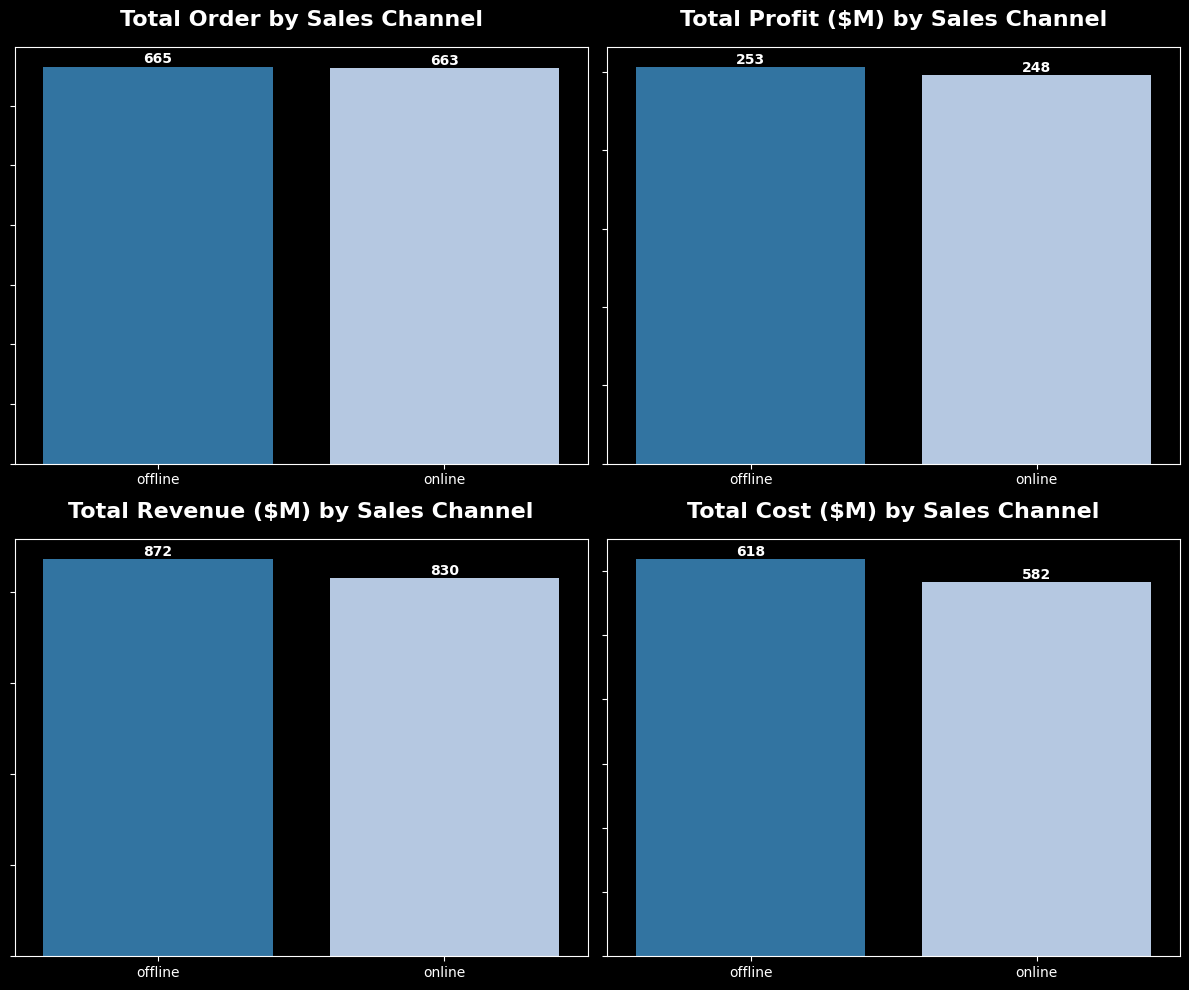

In [ ]:
#Handling sales channel values
clean_sales_data['sales_channel'].unique()
clean_sales_data['sales_channel'] = clean_sales_data['sales_channel'].str.lower()

#Creating plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Creating paletter
sales_channel_list = sorted(clean_sales_data['sales_channel'].unique())
palette = sns.color_palette("tab20", n_colors=len(sales_channel_list))
sales_channel_colors = dict(zip(sales_channel_list, palette))

#1. Total Orders by sales_channel
order_list = clean_sales_data['sales_channel'].value_counts().index

sns.countplot(
    data = clean_sales_data,
    x = 'sales_channel',
    hue = 'sales_channel',
    palette = sales_channel_colors,
    order = order_list,
    ax = axes[0, 0],
    legend = False
    )

axes[0, 0].set_title(
    "Total Order by Sales Channel",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[0, 0].set_ylabel("")
axes[0, 0].set_xlabel("")
axes[0, 0].set_yticklabels([])

for bar in axes[0, 0].patches:
    height = bar.get_height()
    if height > 0:
        axes[0, 0].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{int(height)}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#2. Total Profit by sales channel
profit_order = clean_sales_data.groupby('sales_channel')['order_profit'].sum().sort_values(ascending=False).index

sns.barplot(
    data = clean_sales_data,
    x = 'sales_channel',
    y = 'order_profit',
    hue = 'sales_channel',
    palette = sales_channel_colors,
    estimator = 'sum',
    errorbar = None,
    order = profit_order,
    ax = axes[0, 1],
    legend = False
    )

axes[0, 1].set_title(
    "Total Profit ($M) by Sales Channel",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[0, 1].set_ylabel("")
axes[0, 1].set_xlabel("")
axes[0, 1].set_yticklabels([])

for bar in axes[0, 1].patches:
    height = bar.get_height()
    if height > 0:
        axes[0, 1].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#3. Total Revenue by sales channel
revenue_order = clean_sales_data.groupby('sales_channel')['order_revenue'].sum().sort_values(ascending=False).index

sns.barplot(
    data = clean_sales_data,
    x = 'sales_channel',
    y = 'order_revenue',
    hue = 'sales_channel',
    palette = sales_channel_colors,
    estimator = 'sum',
    errorbar = None,
    order = revenue_order,
    ax = axes[1, 0],
    legend = False
    )

axes[1, 0].set_title(
    "Total Revenue ($M) by Sales Channel",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[1, 0].set_ylabel("")
axes[1, 0].set_xlabel("")
axes[1, 0].set_yticklabels([])

for bar in axes[1, 0].patches:
    height = bar.get_height()
    if height > 0:
        axes[1, 0].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

#4. Total Cost by sales channel
cost_order = clean_sales_data.groupby('sales_channel')['order_cost'].sum().sort_values(ascending=False).head(10).index

sns.barplot(
    data = clean_sales_data,
    x = 'sales_channel',
    y = 'order_cost',
    hue = 'sales_channel',
    palette = sales_channel_colors,
    estimator = 'sum',
    errorbar = None,
    order = cost_order,
    ax = axes[1, 1],
    legend = False
    )

axes[1, 1].set_title(
    "Total Cost ($M) by Sales Channel",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")
axes[1, 1].set_yticklabels([])

for bar in axes[1, 1].patches:
    height = bar.get_height()
    if height > 0:
        axes[1, 1].text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

plt.tight_layout()
plt.show()

Kanały sprzedaży **offline** i **online** wykazują niemal identyczną efektywność, generując zbliżoną liczbę zamówień (odpowiednio **665** i **663**) oraz **zysk na poziomie ok. 250 mln USD**.

###Dynamika sprzedaży wg. kategorii produktów

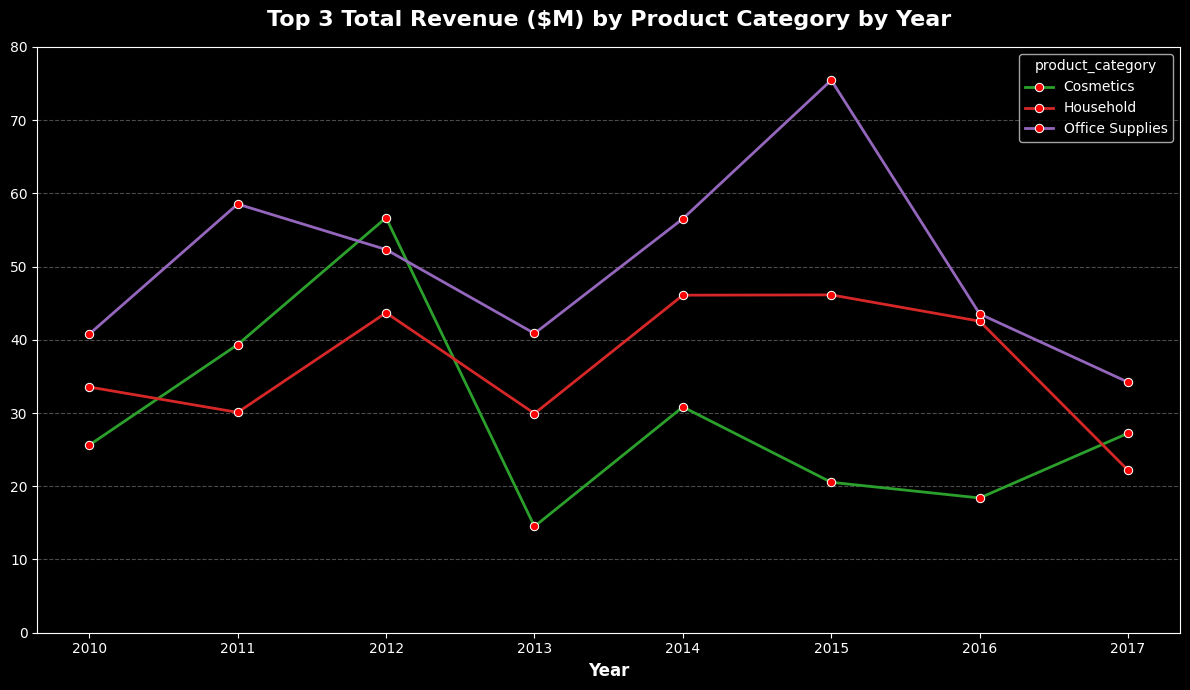

In [ ]:
#Extracting year for order date
clean_sales_data['order_year'] = clean_sales_data['order_date'].dt.year

#Grouping revenue by category
product_category_revenue = clean_sales_data.groupby('product_category')['order_revenue'].sum().reset_index().sort_values(by='order_revenue', ascending=False)

#Identification of Top 3 categories
top_3_revenue_categories = product_category_revenue['product_category'].head(3).tolist()

#Grouping revenue by category & year
sales_dynamics_by_category = clean_sales_data.groupby(['product_category', 'order_year'])['order_revenue'].sum().reset_index()

#Top 3 Total Revenue by country per year
yearly_sales_dynamics_by_top_3_category = sales_dynamics_by_category[sales_dynamics_by_category['product_category'].isin(top_3_revenue_categories)]
yearly_sales_dynamics_by_top_3_category.loc[:, 'order_revenue'] = yearly_sales_dynamics_by_top_3_category['order_revenue'] / 1_000_000
yearly_sales_dynamics_by_top_3_category.loc[:, 'order_revenue'] = yearly_sales_dynamics_by_top_3_category['order_revenue'].round(2)

#Creating plot
plt.figure(figsize=(12, 7))

sns.lineplot(
    data = yearly_sales_dynamics_by_top_3_category,
    x = 'order_year',
    y = 'order_revenue',
    hue = 'product_category',
    palette = category_colors,
    estimator = 'sum',
    linewidth = 2,
    marker = 'o',
    markersize = 6,
    markerfacecolor = 'red'
    )

plt.title(
    "Top 3 Total Revenue ($M) by Product Category by Year",
    fontsize=16,
    fontweight='bold',
    pad=15
    )


plt.xlabel(
    'Year',
    fontsize = 12,
    fontweight = 'bold'
    )
axes[0, 1].set_yticklabels([])
axes[0, 1].tick_params(axis='x', rotation=45)

plt.ylabel("")

y_ticks_ysd = np.arange(0, plt.gca().get_ylim()[1] + 5, 10)
plt.yticks(y_ticks_ysd)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



Wykres przedstawia wahania przychodów trzech głównych kategorii produktów w latach 2010–2017, wskazując na dominację sektora **Office Supplies**, który osiągnął najwyższy szczyt sprzedaży (ponad 75 mln USD) w 2015 roku. Podczas gdy kategorie Household i Cosmetics wykazują dużą zmienność i przeplatające się trendy, na koniec badanego okresu wszystkie trzy segmenty odnotowały wyraźny spadek wartości, zbiegając się w przedziale 20–35 mln USD.

###Dynamika sprzedaży wg. regionów

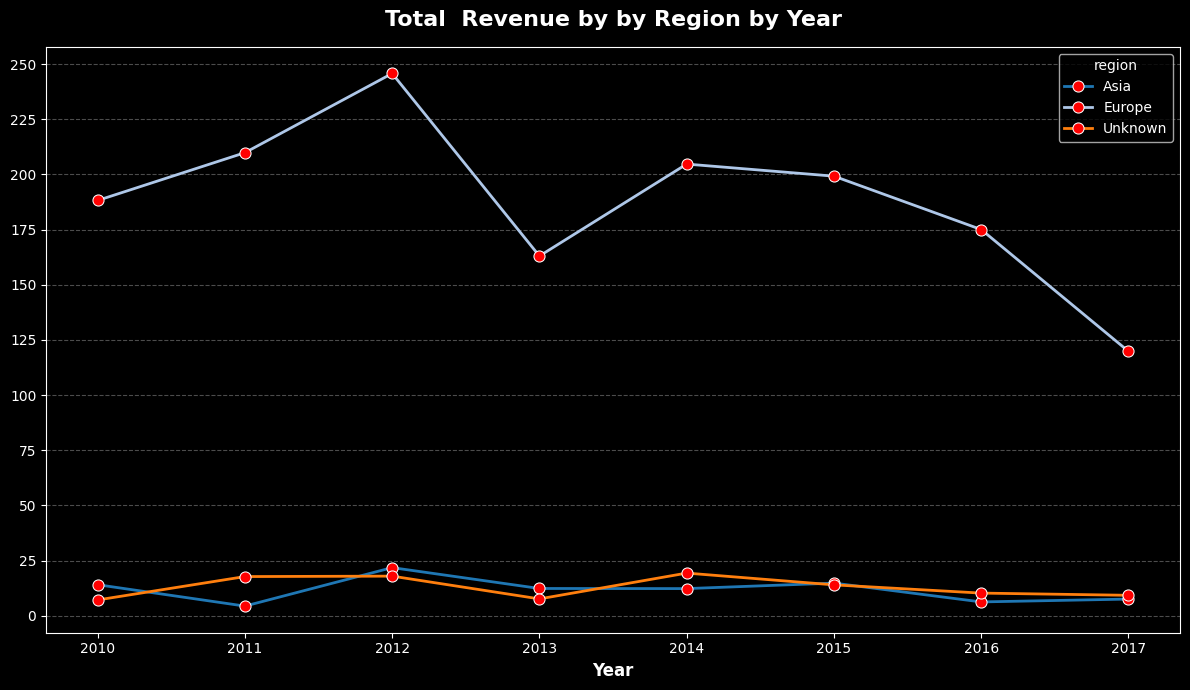

In [ ]:

#Grouping revenue by region
region_revenue = clean_sales_data.groupby('region')['order_revenue'].sum().reset_index().sort_values(by='order_revenue', ascending=False)

#Identification of regions
region_list = region_revenue['region'].tolist()

#Grouping revenue by region & year
sales_dynamics_by_region = clean_sales_data.groupby(['region', 'order_year'])['order_revenue'].sum().reset_index()
sales_dynamics_by_region['order_revenue'] = sales_dynamics_by_region['order_revenue'] / 1_000_000
sales_dynamics_by_region['order_revenue'] = sales_dynamics_by_region['order_revenue'].round(2)

#Creating plot
plt.figure(figsize=(12, 7))

sns.lineplot(
    data = sales_dynamics_by_region,
    x = 'order_year',
    y = 'order_revenue',
    hue = 'region',
    palette = region_colors,
    estimator = 'sum',
    linewidth = 2,
    marker = 'o',
    markersize = 8,
    markerfacecolor = 'red'
    )

plt.title(
    "Total  Revenue by by Region by Year",
    fontsize=16,
    fontweight='bold',
    pad=15
    )


plt.xlabel(
    'Year',
    fontsize = 12,
    fontweight = 'bold'
    )
axes[0, 1].set_yticklabels([])
axes[0, 1].tick_params(axis='x', rotation=45)

plt.ylabel("")

y_ticks_ysd = np.arange(0, plt.gca().get_ylim()[1] + 5, 25)
plt.yticks(y_ticks_ysd)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


**Rynek europejski** utrzymuje pozycję lidera przychodów na przestrzeni całego badanego okresu, osiągając swój szczyt w **2012 roku**. Pozostałe regiony (**Asia** oraz **Unknown**) wykazują znacznie niższą, ale stabilną dynamikę. Od 2014 roku zauważalny jest sukcesywny trend spadkowy przychodów w Europie, który w 2017 roku doprowadził do najniższego wyniku w historii zestawienia.

###Dynamika sprzedaży wg. krajów

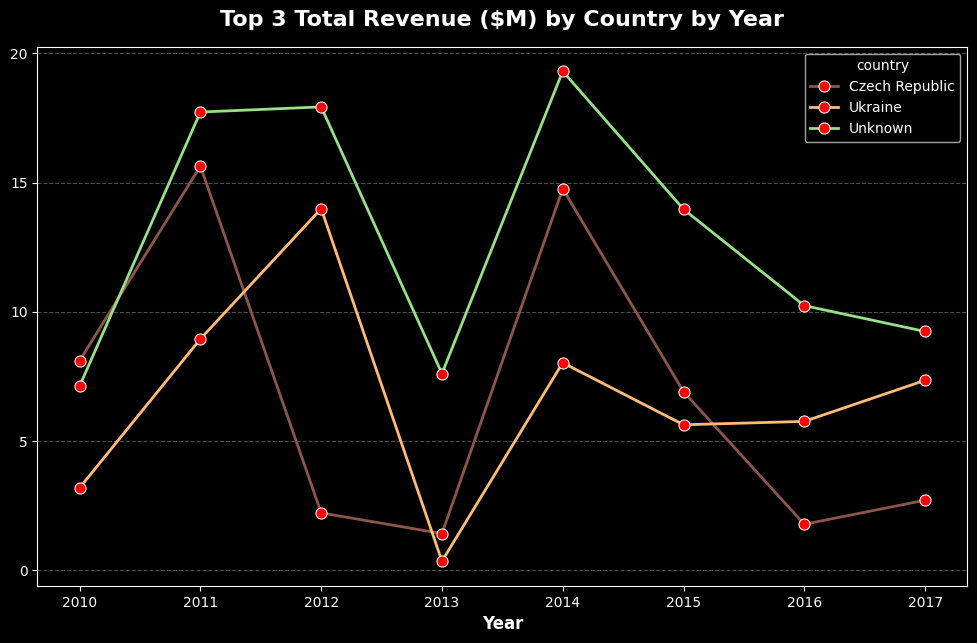

In [ ]:
#Grouping revenue by country
country_revenue = clean_sales_data.groupby('country')['order_revenue'].sum().reset_index().sort_values(by='order_revenue', ascending=False)

#Identification of Top 3 countries
top_3_revenue_countries = country_revenue['country'].head(3).tolist()

#Grouping revenue by country & year
sales_dynamics_by_country = clean_sales_data.groupby(['country', 'order_year'])['order_revenue'].sum().reset_index()

#Top 3 Total Revenue by country per year
yearly_sales_dynamics_by_top_3_countries = sales_dynamics_by_country[sales_dynamics_by_country['country'].isin(top_3_revenue_countries)]
yearly_sales_dynamics_by_top_3_countries.loc[:, 'order_revenue'] = yearly_sales_dynamics_by_top_3_countries['order_revenue'] / 1_000_000
yearly_sales_dynamics_by_top_3_countries.loc[:, 'order_revenue'] = yearly_sales_dynamics_by_top_3_countries['order_revenue'].round(2)

#Creating plot
plt.figure(figsize=(12, 7))

sns.lineplot(
    data = yearly_sales_dynamics_by_top_3_countries,
    x = 'order_year',
    y = 'order_revenue',
    hue = 'country',
    palette = country_colors,
    estimator = 'sum',
    linewidth = 2,
    marker = 'o',
    markersize = 8,
    markerfacecolor = 'red'
    )

plt.title(
    "Top 3 Total Revenue ($M) by Country by Year",
    fontsize=16,
    fontweight='bold',
    pad=15
    )


plt.xlabel(
    'Year',
    fontsize = 12,
    fontweight = 'bold'
    )
axes[0, 1].set_yticklabels([])
axes[0, 1].tick_params(axis='x', rotation=45)

plt.ylabel("")

y_ticks_ysd = np.arange(0, plt.gca().get_ylim()[1] + 2, 5)
plt.yticks(y_ticks_ysd)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


Wykres przedstawia dużą zmienność przychodów w czasie, z rekordowym wynikiem kategorii Unknown, która w 2014 roku osiągnęła niemal 20 mln USD. Trendy dla Czech i Ukrainy są mocno nieregularne i cechują się licznymi wahaniami, przy czym rok 2013 był okresem wyraźnego kryzysu sprzedażowego dla wszystkich trzech grup.

###Analiza sprzedaży wg. dni tygodnia

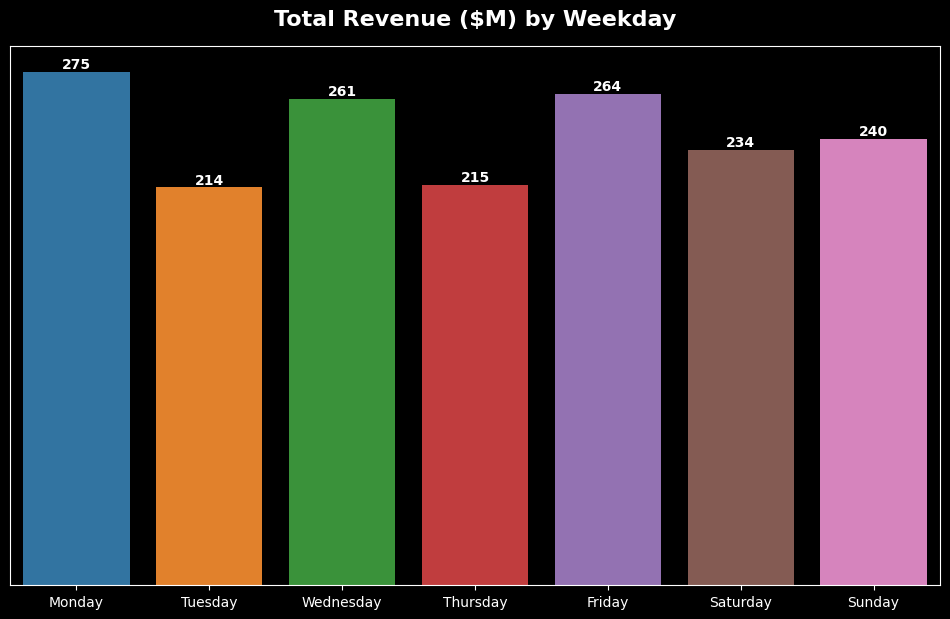

In [ ]:
#Extracting day for order date
clean_sales_data['order_day'] = clean_sales_data['order_date'].dt.day_name()

#Creating order
days_order = list(calendar.day_name)

#Creating color palette
day_list = days_order
palette = sns.color_palette("tab10", n_colors=len(day_list))
day_colors = dict(zip(day_list, palette))

#Creating plot
plt.figure(figsize=(12, 7))

total_revenue_by_weekday_plot = sns.barplot(
   data = clean_sales_data,
    x = 'order_day',
    y = 'order_revenue',
    hue = 'order_day',
    palette = day_colors,
    estimator = 'sum',
    errorbar = None,
    order = days_order,
    legend = False
)

plt.title(
    "Total Revenue ($M) by Weekday",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

plt.ylabel("")
plt.xlabel("")
plt.yticks([])

for bar in total_revenue_by_weekday_plot.patches:
    height = bar.get_height()
    if height > 0:
        total_revenue_by_weekday_plot.text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height + 0.5,
            s = f"{height / 1000000:.0f}",
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

plt.show()

Sprzedaż osiąga swój najwyższy poziom w **poniedziałki**, generując rekordowe **275 mln USD przychodu**, po czym gwałtownie spada w kolejne dni robocze. Najniższą aktywność transakcyjną odnotowuje się we wtorki i czwartki (ok. **214–215 mln USD**), natomiast weekendy wykazują umiarkowaną stabilizację na poziomie średnio 237 mln USD.

###Wskaźniki korelacji zysk - czas wysyłki

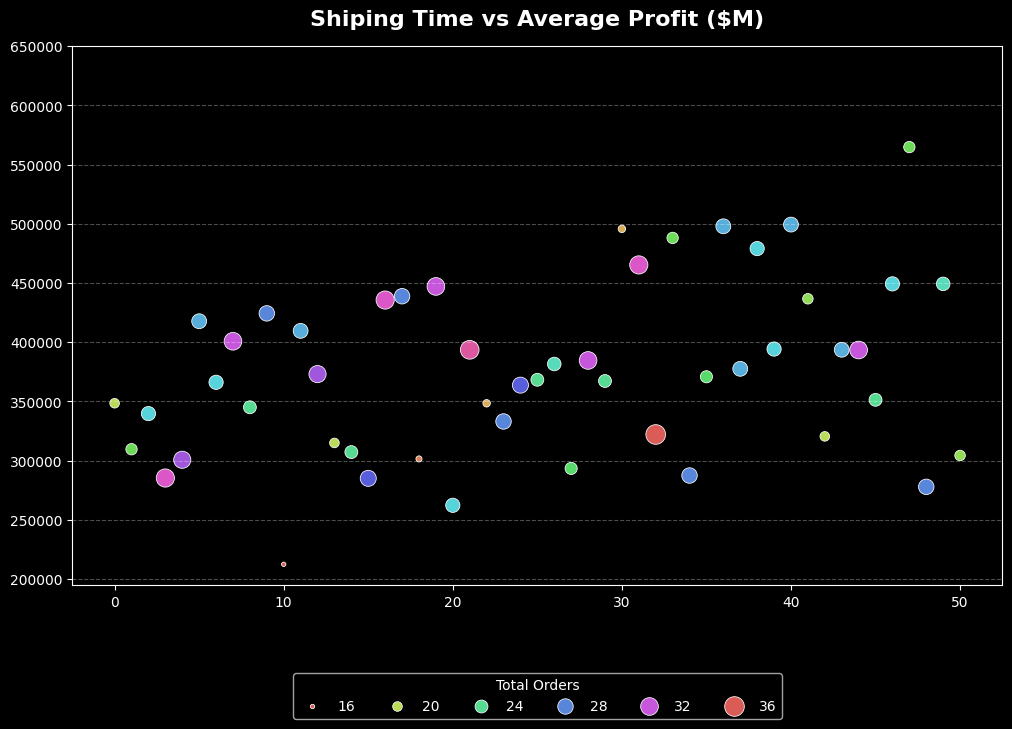

In [ ]:
#Calculate the number of days between ship_date & order_date
clean_sales_data['aging'] = clean_sales_data['ship_date'] - clean_sales_data['order_date']
clean_sales_data['aging'] = clean_sales_data['aging'].dt.days

#Grouping profit by aging
shiping_time_vs_profit = clean_sales_data.groupby('aging').agg(
    avg_order_profit = ('order_profit', 'mean'),
    count_order = ('order_id', 'count')
    ).reset_index()

shiping_time_vs_profit = shiping_time_vs_profit.sort_values(by = 'aging', ascending=False)

#Creating plot
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data = shiping_time_vs_profit,
    x = 'aging',
    y = 'avg_order_profit',
    hue = 'count_order',
    size = 'count_order',
    sizes = (10, 200),
    alpha = 1,
    palette = 'hls'
    )

plt.title(
    "Shiping Time vs Average Profit ($M)",
    fontsize=16,
    fontweight='bold',
    pad=15
    )

plt.legend(
    title='Total Orders',
    bbox_to_anchor=(0.5, -0.15),
    loc='upper center',
    ncol=6
    )

y_ticks_agging = np.arange(200000, shiping_time_vs_profit['avg_order_profit'].max() + 100000, 50000)
plt.yticks(y_ticks_agging)
plt.ylabel("")
plt.xlabel("")

plt.grid(axis = 'y', linestyle = '--', alpha = 0.3)

plt.show()


Wykres punkowy pokazuje brak bezpośredniej zależności między czasem wysyłki a średnim zyskiem, który dla większości zamówień oscyluje w granicach **300–500 tys. USD**.

###Analiza czasu potrzebnego na wysyłkę wg. kategorii produktów


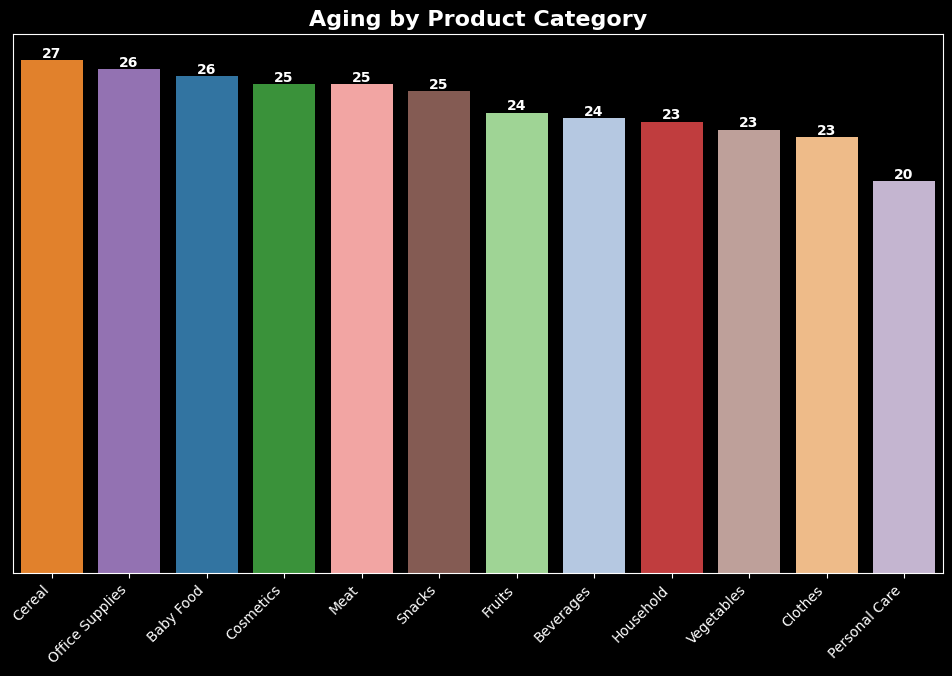

In [ ]:
#Creating order
order_list = clean_sales_data.groupby('product_category')['aging'].mean().sort_values(ascending=False).index

#Creating plot
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data = clean_sales_data,
    x = 'product_category',
    y = 'aging',
    errorbar = ('ci', False),
    palette = category_colors,
    order = order_list,
    hue = 'product_category',
    legend = False
    )

plt.title('Aging by Product Category',
    fontsize = 16,
    fontweight = 'bold'
          )

plt.ylabel("")
plt.xlabel("")
plt.yticks([])

plt.xticks(rotation=45, ha='right')

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height,
            s = f'{int(height)}',
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

plt.show()

Wykres  przedstawia średni czas realizacji wysyłki dla poszczególnych kategorii produktów, który waha się w przedziale od **20 do 27 dni**. Najdłuższy czas oczekiwania dotyczy kategorii **Cereal** (**27 dni**) oraz **Office Supplies** i **Baby Food** (po **26 dni**). Najsprawniej realizowane są zamówienia w kategorii **Personal Care**, gdzie średni czas wysyłki jest najkrótszy i wynosi **20 dni**.

###Analiza czasu potrzebnego na wysyłkę wg. kraju

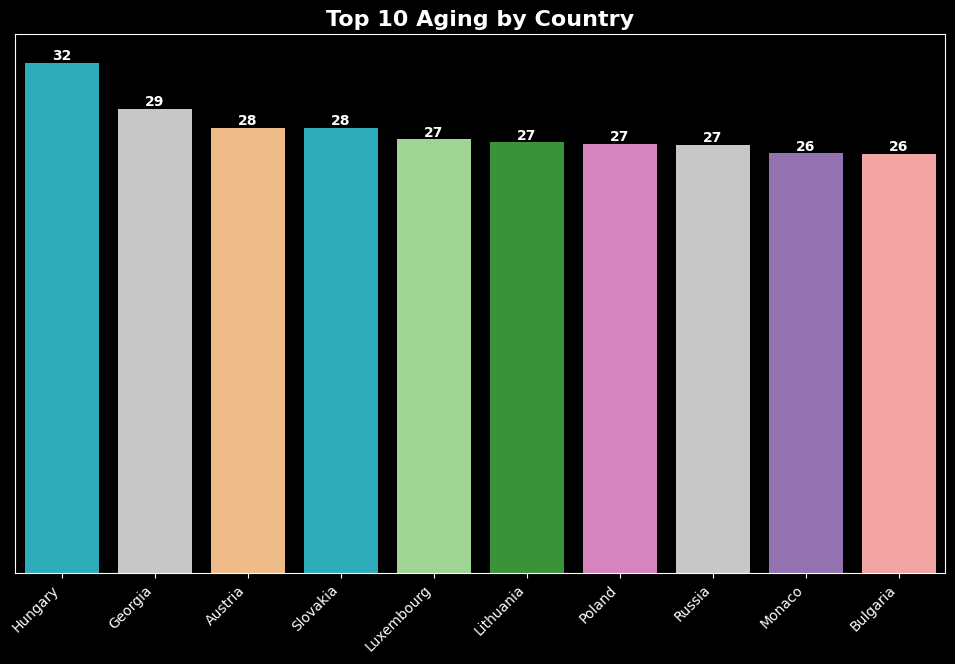

In [ ]:
#Creating order
top_10_order = (
    clean_sales_data.groupby('country')['aging']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

#Filtering
top_10_data = clean_sales_data[clean_sales_data['country'].isin(top_10_order)]

#Creating plot
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data = top_10_data,
    x = 'country',
    y = 'aging',
    errorbar = ('ci', False),
    palette = country_colors,
    order = top_10_order,
    hue = 'country',
    legend = False
    )

plt.title('Top 10 Aging by Country',
    fontsize = 16,
    fontweight = 'bold'
          )

plt.ylabel("")
plt.xlabel("")
plt.yticks([])

plt.xticks(rotation=45, ha='right')

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height,
            s = f'{int(height)}',
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

plt.show()

Wykres prezentuje zestawienie krajów z najdłuższym czasem oczekiwania na wysyłkę zamówień, gdzie niechlubnym liderem są **Węgry** z wynikiem **32 dni**. Pozostałe państwa w rankingu, w tym **Gruzja**, **Austria** i **Polska**, wykazują wysokie opóźnienia oscylujące w granicach **26–29 dni**, co sugeruje systemowe problemy z logistyką lub procesowaniem paczek.

###Analiza czasu potrzebnego na wysyłkę wg. regionu

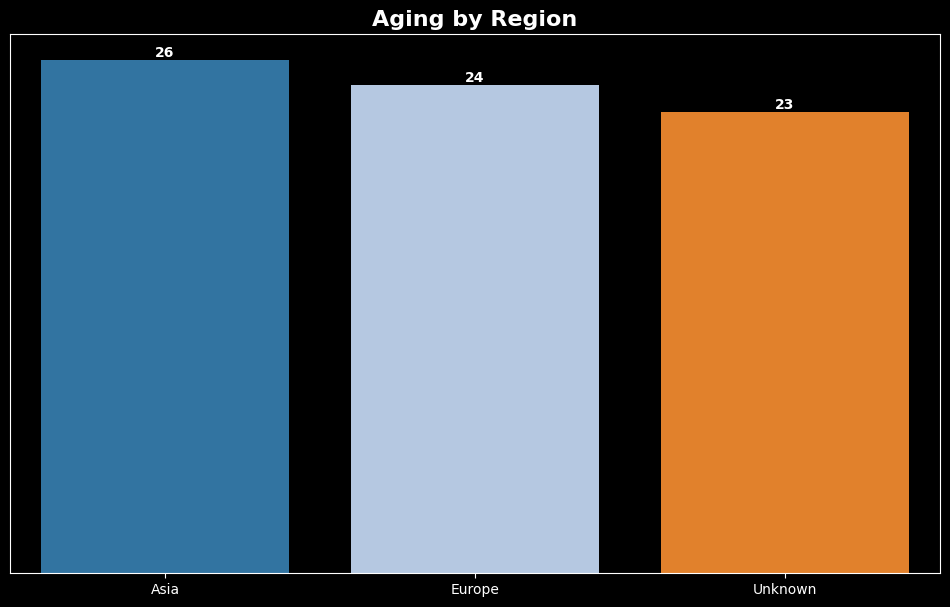

In [ ]:
#Creating order
order_list  = clean_sales_data.groupby('region')['aging'].mean().sort_values(ascending=False).index

#Creating plot

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data = clean_sales_data,
    x = 'region',
    y = 'aging',
    errorbar = None,
    palette = region_colors,
    order = order_list,
    hue = 'region',
    legend = False
)

plt.title('Aging by Region',
    fontsize = 16,
    fontweight = 'bold'
          )

plt.ylabel("")
plt.xlabel("")
plt.yticks([])

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.text(
            x = bar.get_x() + bar.get_width() / 2,
            y = height,
            s = f'{int(height)}',
            ha = "center",
            va = "bottom",
            fontsize = 10,
            fontweight = 'bold'
        )

plt.show()

Wszystkie trzy obszary wykazują **zbliżoną efektywność wysyłki**. Różnica zaledwie **3 dni** między skrajnymi regionami sugeruje względną spójność operacyjną firmy w skali globalnej.

#4. Podsumowanie

##Oczyszczanie i integracja danych

1. Zbiór `events_data`

W celu zachowania rzetelności analizy sprzedaży podjęto decyzję o:
- **Korekcie braków danych**: Usunięto wiersze z brakującymi wartościami w  kolumnie:
  - `Units Sold`: usunięto 2 wiersze (**0,15%** zbioru).
- **Uzupełnieniu braków danych**: Uzupełniono wiersze z brakującymi wartościami w  kolumnie:  
  - `Country Code`: Wartością `unknown` uzupełniono 82 wiersze (**6,16%** zbioru), co było niezbędne do poprawnej agregacji geograficznej.

**Charakterystyka wolumenu sprzedaży**: Analiza rozkładu w kolumnie` Units Sold` wykazała wysoką symetrię zbioru (średnia: $4952$, mediana: $4962$). Mimo dużego rozrzutu wartości, brak znaczącej asymetrii pozwala na stabilne wnioskowanie statystyczne.
- *Rekomendacja*: W dalszym etapie analizy zaleca się wprowadzenie segmentacji zamówień ze względu na wolumen (np. zamówienia mało-, średnio- i wielkoilościowe).

2. Zbiór `countries_data`

Dokonano optymalizacji bazy krajów poprzez usunięcie rekordów nieposiadających wartości analitycznej:

- **Namibia**: Usunięta ze względu na brak kodu `alpha-2` oraz brak powiązanych transakcji w tabeli zdarzeń.

- **Antarctica**: Usunięta z powodu braku przypisania do regionu i subregionu oraz braku aktywności sprzedażowej.

3. Integracja danych

- Utworzono poprawione zbiory : `clean_events_data, clean_products_data` oraz `clean_countries_data`.

- Finalna tabela analityczna `clean_sales_data` powstała z połączenia powyższych zbiorów i stanowi ujednoliconą bazę dla wszystkich zestawień oraz wizualizacji zawartych w raporcie


##Ograniczenia danych

- **Brak identyfikacji krajów**: Zbiór zawiera wiele nieznanych wartości w kolumnie `country` co ma znaczący wpływ na wskaźniki sprzedaży.

- **Brak identyfikacji nabywców**: Zbiór nie zawiera unikalnych identyfikatorów klientów.

- **Sztywność parametrów cenowych**: Dane opierają się na stałych cenach jednostkowych. Brak informacji o udzielonych rabatach, akcjach promocyjnych czy wyprzedażach sezonowych może wpływać na odchylenia między raportowanym a faktycznym przychodem ze sprzedaży.

- **Uproszczony model rentownośc**i: Wyliczenia dotyczące zysku i kosztów mają charakter operacyjny i opierają się wyłącznie na różnicy między ceną zakupu a sprzedaży. Model nie uwzględnia kosztów zmiennych (np. logistyka i spedycja) oraz kosztów stałych (np. wynagrodzenia, najm powierzchni, media), co prowadzi do przeszacowania marży.

- **Niewyjaśniona zmienność czasu realizacji**: Odnotowano znaczne rozbieżności w czasie między datą zamówienia a wysyłką. Ze względu na brak danych kontekstowych (stany magazynowe, procesy logistyczne, dostępność towaru), nie jest możliwa precyzyjna identyfikacja przyczyn opóźnień.


##Raport

1. **Podsumowanie wyników finansowych:**
    - **Przychody całkowite**: 1 702 129 408,21 USD (~1,7 mld USD)
    - **Koszty całkowite**: 1 200 694 949,21 USD (~1,2 mld USD)
    - **Zysk całkowity:** 501 434 459 USD (~501 mln USD)
    - **Skala operacji**: 1 328 zamówień z 45 krajów.

2. **Analiza Kategorii Produktowych**
    - **Cosmetics**: to lider zysku (**93 mln USD**), mimo że pod względem liczby zamówień (**114**) zajmuje dopiero piąte miejsce. Świadczy to o bardzo wysokiej marży w tej kategorii.
    - **Office Supplies**: Generuje największy przychód (**402 mln USD**) i największą liczbę zamówień (**123**), ale pod względem zysku (**78 mln USD**) ustępuje produktom z kategorii Cosmetics.
    - **Fruits**: Mimo średniej liczby zamówień  (**112**), generuje ona marginalne zyski (**1 mln USD**). Jest to  kategoria o bardzo niskiej marży.

3. **Analiza Regionalna i Geograficzna**

    **Dominacja Europy:**
    - **Europa** odpowiada za lwią część biznesu: **1164 zamówienia**  i **449 mln USD zysku**.
    - **Azja** pozostaje rynkiem niszowym dla firmy: tylko **82 zamówienia i 25 mln USD zysku**.
    - **Kategoria** `Unknown` wykazuje wyniki zbliżone do Azji, co sugeruje potrzebę lepszej kategoryzacji danych geograficznych

    **Ranking Krajów:**

    - **Pod względem liczby zamówień**: Najwięcej zamówień przypisanych jest do kategorii **Unknown** (**82**). Wśród zidentyfikowanych państw przodują **San Marino** oraz **Andora** (po **40** zamówień), a zaraz za nimi plasuje się **Rumunia** (**34**).

    - **Pod względem zysku**: Poza kategorią **Unknown** (**28 mln USD**), najbardziej dochodowymi rynkami są** Andora**, **Ukraina** oraz **Malta** – każdy z tych krajów wygenerował po **15 mln USD** zysku. Tuż za nimi plasują się **San Marino**, **Węgry**, **Macedonia** oraz **Czechy** z wynikiem **14 mln USD**.

4. **Kanały Sprzedaży**

    Firma osiągnęła niemal **idealny balans** między sprzedażą tradycyjną a internetową
    - **Offline**: 665 zamówień, 872 mln USD przychodu i **253 mln USD zysku**
    - **Online**: 663 zamówień, 830 mln USD przychodu i **248 mln USD zysku**

5. **Analiza Trendów**

    - **Piki sprzedażowe**: Najlepsze wyniki firma odnotowała w latach **2012** oraz **2015**. W 2015 roku kategoria **Office Supplies** osiągnęła rekordowy przychód ponad **75,5 mln USD**.

    - **Wahania w krajach**:
      - **Czechy** odnotowały dwa wyraźne szczyty przychodówt w **2011** oraz **2014** roku. Pomiędzy tymi latami oraz po 2014 roku nastąpiły gwałtowne spadki.

      - **Ukraina** wykazała najbardziej dynamiczny wzrost w latach 2013–2014.
      

6. **Wydajność Sprzedaży według Dni Tygodnia**

    - **Poniedziałek**: Lider sprzedaży. Największy przychód spośrób wszystkich dni tygodnia (**275 mln USD**)

    - **Wtorek i Czwartek**: Wyraźne *"dołki"* w aktywności transakcyjnej.

    - **Sobota i Niedziela**: Stabilna sprzedaż weekendowa (prawdopodobnie w kanale online)

7. **Analiza zależności zysku od czasu potrzebnego na wysyłkę**

    Wizualizacja wskazuje duże rozproszenie danych. Punkty są rozlokowane na niemal całej płaszczyźnie wykresu bez tworzenia wyraźnej linii czy klastrów. Oznacza to, że **średni zysk nie zależy w sposób bezpośredni** od czasu wysyłki.

8. **Analiza Logistyczna (Czas wysyłki zamówienia)**

    **Czas realizacji według kategorii:**

    - **Najdłuższy czas wysyłki**: Produkty z kategorii **Cereal** są wysyłane **średnio po 27 dniach** od zamówienia.

    - **Najkrótszy czas wysyłki**: Produkty z kategorii **Personal Care** są wysyłane **średnio po 20 dniach** od zamówienia.

9. **Położenie geograficzne a logistyka:**
- **Wąskie gardła**: Najdłuższy czas oczekiwania na wysyłkę występuje na Węgrzech (**32 dni**) oraz w Gruzji **(29 dni**).

- **Regiony**: Azja (**26 dni**) i Europa (**24 dni**) wykazują zbliżoną efektywność wysyłki zamówień, co sugeruje, że opóźnienia wynikają raczej z procesów wewnętrznych firmy niż z dystansu geograficznego.


##Rekomendacje

1. **Optymalizacja Struktury Sprzedaży**
    - **Zwiększenie priorytetu** dla kategorii **Cosmetics** oraz **Household** w kampaniach marketingowych, przy jednoczesnej analizie opłacalności dalszego utrzymywania asortymentu w kategorii **Fruits** bez zmiany ich polityki cenowej.

2. **Modernizacja Procesów Logistycznych**
    - **Skrócenie czasu realizacji** zamówienia powinno stać się priorytetem.

3. **Dywersyfikacja Rynkowa**
    - W celu zabezpieczenia długoterminowego wzrostu, zalecane jest **wyjście poza rynek europejski**.
